# Fase 5 CRISP-DM — Evaluation
## Consolidación de Resultados y Recomendaciones de Negocio

**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Validar la coherencia de todos los modelos y análisis, traducir los hallazgos  
técnicos en recomendaciones accionables para el negocio.

Este notebook consolida los resultados de las fases anteriores:
| Fase | Notebook | Resultado principal |
|------|----------|--------------------|
| 2 — Data Understanding | `01_eda.ipynb` | EDA completo: calidad, distribuciones, tendencias |
| 3 — Data Preparation | `02_data_prep.ipynb` | `olist_master.csv`: 96,457 pedidos, 18 variables |
| 4 — Modeling (reviews) | `03_negative_reviews.ipynb` | Top 3 drivers de reseña negativa |
| 4 — Modeling (RFM) | `04_rfm_segmentation.ipynb` | 6 segmentos de cliente, 93,337 clientes |

---

## 0. Imports y configuración

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

ROOT    = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"
MASTER  = ROOT / "data" / "olist_master.csv"
RFM_CSV = ROOT / "data" / "olist_rfm.csv"
DASH    = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.2f}".format)

SEG_COLORS = {
    "Champions":     "#1a9850",
    "Loyal":         "#91cf60",
    "New Customers": "#4393c3",
    "At Risk":       "#fc8d59",
    "Lost":          "#d73027",
    "Others":        "#aaaaaa",
}

for p in [MASTER, RFM_CSV, DB_PATH]:
    print(f"{'OK' if p.exists() else 'MISSING':>7}  {p.name}")

     OK  olist_master.csv
     OK  olist_rfm.csv
     OK  olist.db


---
## 1. Carga de datos

In [2]:
master = pd.read_csv(MASTER, parse_dates=["order_purchase_timestamp"])
rfm    = pd.read_csv(RFM_CSV)

# Subconjunto con reseña para análisis de satisfacción
master_rev = master.dropna(subset=["review_score"]).copy()
master_rev["review_score"]       = master_rev["review_score"].astype(int)
master_rev["is_negative_review"] = (master_rev["review_score"] <= 2).astype(int)

# Retención por categoría desde SQLite
conn = sqlite3.connect(DB_PATH)
retention_sql = (ROOT / "sql" / "03_retention.sql").read_text(encoding="utf-8")
retention_df  = pd.read_sql(retention_sql, conn)
conn.close()

print(f"master:       {master.shape}")
print(f"master_rev:   {master_rev.shape}  (con reseña)")
print(f"rfm:          {rfm.shape}")
print(f"retention:    {retention_df.shape}  (top 20 categorías por retención)")

master:       (96457, 20)
master_rev:   (95811, 20)  (con reseña)
rfm:          (93337, 10)
retention:    (58, 9)  (top 20 categorías por retención)


---
## 2. Evaluación de segmentos RFM

### 2.1 Tabla resumen: R, F, M medias por segmento
Verificamos que cada segmento tenga un perfil de comportamiento coherente con su definición.  
Un segmento válido debe ser distinguible de los demás en al menos una dimensión clave.

In [3]:
seg_order = ["Champions", "Loyal", "New Customers", "At Risk", "Lost", "Others"]

seg_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        n_customers      =("customer_unique_id", "count"),
        pct_customers    =("customer_unique_id", lambda x: len(x) / len(rfm) * 100),
        avg_recency      =("recency",            "mean"),
        med_recency      =("recency",            "median"),
        avg_frequency    =("frequency",           "mean"),
        avg_monetary     =("monetary",            "mean"),
        med_monetary     =("monetary",            "median"),
        total_revenue    =("monetary",            "sum"),
        pct_revenue      =("monetary",            lambda x: x.sum() / rfm["monetary"].sum() * 100),
        avg_R            =("R_score",             "mean"),
        avg_F            =("F_score",             "mean"),
        avg_M            =("M_score",             "mean"),
        avg_RFM_score    =("RFM_score",           "mean"),
    )
)

# Ordenar según seg_order definido
seg_summary["order"] = seg_summary["segment"].map({s: i for i, s in enumerate(seg_order)})
seg_summary = seg_summary.sort_values("order").drop(columns="order").reset_index(drop=True)

display_cols = [
    "segment", "n_customers", "pct_customers",
    "avg_recency", "avg_frequency", "avg_monetary",
    "pct_revenue", "avg_R", "avg_F", "avg_M", "avg_RFM_score",
]
display(
    seg_summary[display_cols]
    .rename(columns={
        "segment": "Segmento", "n_customers": "Clientes",
        "pct_customers": "% clientes", "avg_recency": "Recency (días)",
        "avg_frequency": "Frequency", "avg_monetary": "Monetary (BRL)",
        "pct_revenue": "% revenue", "avg_R": "R_score",
        "avg_F": "F_score", "avg_M": "M_score", "avg_RFM_score": "RFM_score",
    })
    .set_index("Segmento")
    .round(2)
    .style
    .background_gradient(subset=["R_score", "F_score", "M_score", "RFM_score"], cmap="RdYlGn")
    .format({
        "Clientes": "{:,.0f}", "% clientes": "{:.1f}%",
        "Recency (días)": "{:.0f}", "Frequency": "{:.2f}",
        "Monetary (BRL)": "R${:.1f}", "% revenue": "{:.1f}%",
    })
)

,Clientes,% clientes,Recency (días),Frequency,Monetary (BRL),% revenue,R_score,F_score,M_score,RFM_score
Segmento,,,,,,,,,,
Champions,121,0.1%,89,3.51,R$461.5,0.4%,4.500000,5.000000,4.700000,4.730000
Loyal,"1,689",1.8%,135,2.03,R$253.5,3.2%,3.970000,3.040000,4.170000,3.730000
New Customers,"36,132",38.7%,90,1.00,R$140.3,38.4%,4.500000,1.000000,2.990000,2.830000
At Risk,991,1.1%,382,2.08,R$246.6,1.9%,1.560000,3.140000,4.050000,2.920000
Lost,"36,344",38.9%,395,1.00,R$139.6,38.4%,1.500000,1.000000,2.950000,1.820000
Others,"18,060",19.4%,220,1.00,R$129.9,17.8%,3.000000,1.000000,2.950000,2.320000


### 2.2 Validación de coherencia de segmentos
Verificamos que los scores R, F, M medios de cada segmento coincidan con la lógica de negocio definida en el notebook 04.

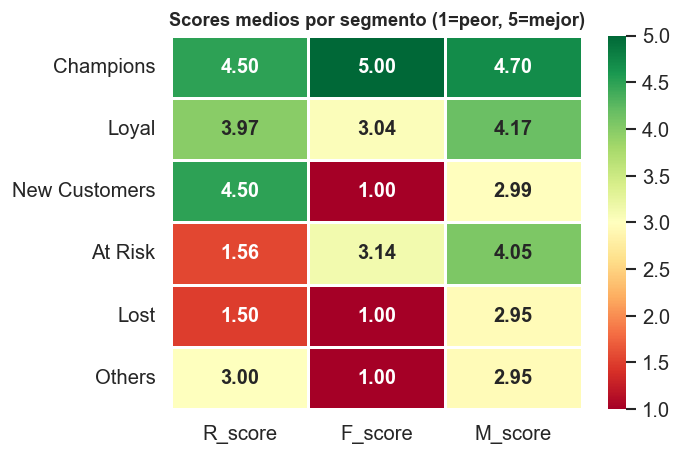

In [4]:
# Heatmap de scores medios por segmento
score_pivot = seg_summary.set_index("segment")[["avg_R", "avg_F", "avg_M"]].loc[
    [s for s in seg_order if s in seg_summary["segment"].values]
]
score_pivot.columns = ["R_score", "F_score", "M_score"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    score_pivot, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.8, ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
)
ax.set_title("Scores medios por segmento (1=peor, 5=mejor)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(DASH / "eval_rfm_scores_heatmap.png", bbox_inches="tight")
plt.show()

**Corrección (revisión de portfolio, prioridad 1):** los 4 checks de una versión anterior de
este notebook eran **tautológicos**: comparaban `R_score`/`F_score` entre segmentos que se
DEFINEN por umbrales de esos mismos scores (Champions = R≥4∧F≥4, Lost = R≤2∧F≤2, ...) -- no
pueden fallar salvo un error de código en `assign_segment`, y no comprobaban nada contra
comportamiento real observado. Se sustituyen por checks **falsables** sobre variables que
`assign_segment` NUNCA usa para decidir el segmento: `monetary` (M_score no entra en la regla de
asignación) y `frequency` observada. Si la segmentación fuera ruido (como ocurría antes de
corregir F_score, ver notebook 04 §3), estos NO tendrían por qué cumplirse.

In [5]:
obs = rfm.groupby("segment").agg(
    avg_monetary=("monetary", "mean"), avg_frequency=("frequency", "mean"),
)
print("\nValidación de coherencia de segmentos (checks falsables, no tautológicos):")
checks = [
    ("Champions tiene Monetary medio mayor que Lost (M_score no define el segmento)",
     obs.loc["Champions", "avg_monetary"] > obs.loc["Lost", "avg_monetary"]),
    ("Loyal tiene Monetary medio mayor que New Customers (M_score no define el segmento)",
     obs.loc["Loyal", "avg_monetary"] > obs.loc["New Customers", "avg_monetary"]),
    ("At Risk tiene Frequency observada real y mayor que Lost "
     "(ambos con R≤2; si fuera ruido, serían indistinguibles como antes de la corrección)",
     obs.loc["At Risk", "avg_frequency"] > obs.loc["Lost", "avg_frequency"]),
    ("Champions tiene Frequency observada mayor que New Customers",
     obs.loc["Champions", "avg_frequency"] > obs.loc["New Customers", "avg_frequency"]),
]
all_ok = True
for desc, result in checks:
    icon = "PASS" if result else "FAIL"
    print(f"  [{icon}] {desc}")
    if not result:
        all_ok = False
print(f"\n  Resultado: {'Todos los checks pasaron (segmentación discrimina comportamiento real)' if all_ok else 'Revisar segmentacion'}")
print(f"\n  Referencia -- Monetary medio: Champions={obs.loc['Champions','avg_monetary']:.0f}, "
      f"Loyal={obs.loc['Loyal','avg_monetary']:.0f}, At Risk={obs.loc['At Risk','avg_monetary']:.0f}, "
      f"New Customers={obs.loc['New Customers','avg_monetary']:.0f}, Lost={obs.loc['Lost','avg_monetary']:.0f}")
print(f"  Referencia -- Frequency media: At Risk={obs.loc['At Risk','avg_frequency']:.2f}, "
      f"Lost={obs.loc['Lost','avg_frequency']:.2f} (antes de la corrección ambos eran ~1.0-1.05, "
      f"indistinguibles)")


Validación de coherencia de segmentos (checks falsables, no tautológicos):
  [PASS] Champions tiene Monetary medio mayor que Lost (M_score no define el segmento)
  [PASS] Loyal tiene Monetary medio mayor que New Customers (M_score no define el segmento)
  [PASS] At Risk tiene Frequency observada real y mayor que Lost (ambos con R≤2; si fuera ruido, serían indistinguibles como antes de la corrección)
  [PASS] Champions tiene Frequency observada mayor que New Customers

  Resultado: Todos los checks pasaron (segmentación discrimina comportamiento real)

  Referencia -- Monetary medio: Champions=462, Loyal=254, At Risk=247, New Customers=140, Lost=140
  Referencia -- Frequency media: At Risk=2.08, Lost=1.00 (antes de la corrección ambos eran ~1.0-1.05, indistinguibles)


### 2.3 Perfil de cada segmento
Descripción de negocio de cada grupo basada en los datos reales.

In [6]:
perfiles = {
    "Champions": (
        "Compraron hace poco y con la mayor frecuencia del dataset. "
        "Son el segmento más valioso en términos de monetary promedio. "
        "Acción: programa VIP, early access, referidos activos."
    ),
    "Loyal": (
        "Clientes recurrentes con recency moderada. Buena frecuencia y gasto. "
        "Representan la base estable del negocio. "
        "Acción: upsell a categorías premium, descuentos por volumen."
    ),
    "New Customers": (
        "Compraron recientemente pero solo una vez. Alto potencial de fidelización. "
        "La recency alta indica que la relación está viva. "
        "Acción: onboarding email, descuento en segunda compra, recomendaciones personalizadas."
    ),
    "At Risk": (
        "Clientes que SÍ repitieron compra (frequency≥2, verificado en la Sección 2.2 -- ya no es "
        "ruido) pero llevan mucho tiempo sin comprar. Un grupo pequeño pero genuino (~1% de la "
        "base) que ya demostró disposición a recomprar. "
        "Acción: campaña win-back dirigida con cupón con fecha límite."
    ),
    "Lost": (
        "Compraron una sola vez y llevan mucho tiempo sin volver (frequency=1, R bajo). Es el "
        "segmento más grande del dataset junto con New Customers (~39% cada uno) -- refleja la "
        "tasa de recompra estructuralmente baja de Olist (~3%), no una anomalía de la segmentación. "
        "Acción: campañas de bajo coste; no priorizar sobre At Risk, que sí tiene historial de recompra."
    ),
    "Others": (
        "Combinaciones intermedias de scores que no encajan en los segmentos principales. "
        "Necesitan monitoreo continuo y reclasificación en la siguiente iteración RFM."
    ),
}

print("PERFILES DE SEGMENTOS RFM — OLIST\n" + "=" * 65)
for seg in seg_order:
    row = seg_summary[seg_summary["segment"] == seg]
    if row.empty:
        continue
    row = row.iloc[0]
    print(f"\n[{seg.upper()}]")
    print(f"  Clientes:       {int(row['n_customers']):,} ({row['pct_customers']:.1f}%)")
    print(f"  Recency media:  {row['avg_recency']:.0f} días")
    print(f"  Frequency media:{row['avg_frequency']:.2f} pedidos")
    print(f"  Monetary media: R${row['avg_monetary']:.0f}")
    print(f"  RFM score:      {row['avg_RFM_score']:.2f}/5")
    print(f"  Perfil:         {perfiles.get(seg, '')}")

PERFILES DE SEGMENTOS RFM — OLIST

[CHAMPIONS]
  Clientes:       121 (0.1%)
  Recency media:  89 días
  Frequency media:3.51 pedidos
  Monetary media: R$462
  RFM score:      4.73/5
  Perfil:         Compraron hace poco y con la mayor frecuencia del dataset. Son el segmento más valioso en términos de monetary promedio. Acción: programa VIP, early access, referidos activos.

[LOYAL]
  Clientes:       1,689 (1.8%)
  Recency media:  135 días
  Frequency media:2.03 pedidos
  Monetary media: R$254
  RFM score:      3.73/5
  Perfil:         Clientes recurrentes con recency moderada. Buena frecuencia y gasto. Representan la base estable del negocio. Acción: upsell a categorías premium, descuentos por volumen.

[NEW CUSTOMERS]
  Clientes:       36,132 (38.7%)
  Recency media:  90 días
  Frequency media:1.00 pedidos
  Monetary media: R$140
  RFM score:      2.83/5
  Perfil:         Compraron recientemente pero solo una vez. Alto potencial de fidelización. La recency alta indica que la relación 

### 2.4 Visualización comparativa de segmentos — Radar chart
El radar chart permite comparar los tres scores de cada segmento simultáneamente,  
confirmando visualmente que los segmentos tienen perfiles diferenciados.

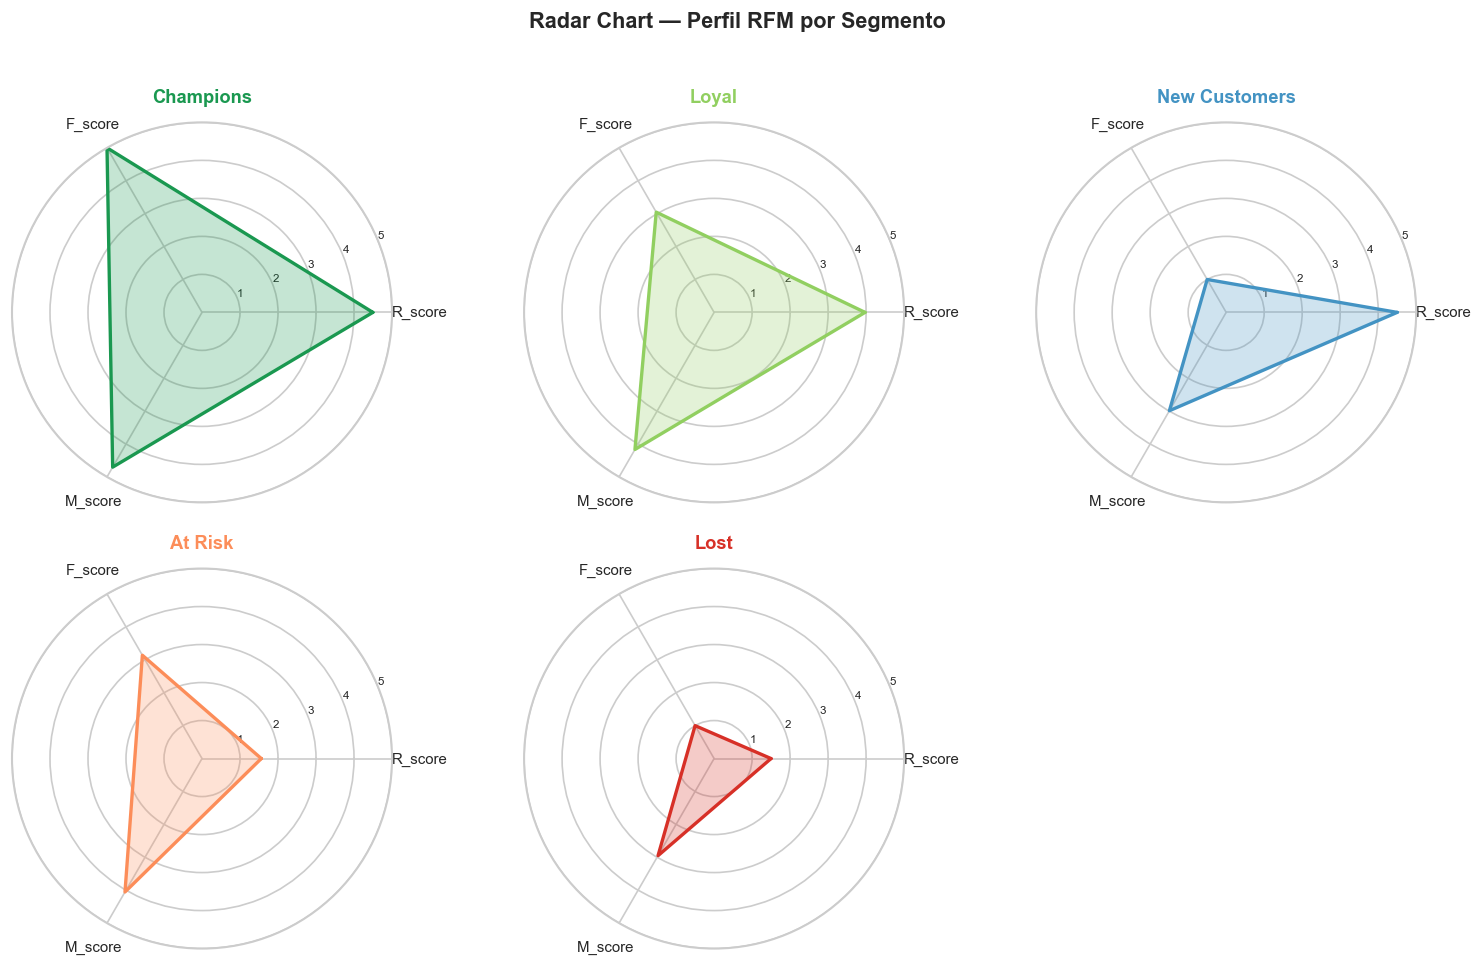

In [7]:
radar_segs = [s for s in seg_order if s != "Others"]
labels     = ["R_score", "F_score", "M_score"]
n_vars     = len(labels)
angles     = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles    += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

for idx, seg in enumerate(radar_segs):
    ax  = axes_flat[idx]
    row = score_pivot.loc[seg] if seg in score_pivot.index else None
    if row is None:
        ax.set_visible(False)
        continue

    vals = row.tolist() + row.tolist()[:1]

    ax.plot(angles, vals, color=SEG_COLORS[seg], linewidth=2)
    ax.fill(angles, vals, color=SEG_COLORS[seg], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7)
    ax.set_ylim(0, 5)
    ax.set_title(seg, fontsize=11, fontweight="bold", pad=12,
                 color=SEG_COLORS[seg])

# Ocultar subplot extra si hay
for idx in range(len(radar_segs), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle("Radar Chart — Perfil RFM por Segmento",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DASH / "eval_radar_segments.png", bbox_inches="tight")
plt.show()

---
## 3. Evaluación de retención por categoría

### 3.1 Top 3 mayor retención vs Top 3 menor retención
Datos provenientes de `sql/03_retention.sql` (Window Functions sobre SQLite).
Solo se consideran categorías con al menos 50 clientes para significancia estadística.

**Corrección (revisión de portfolio, prioridad 3):** una versión anterior de `03_retention.sql`
tenía `LIMIT 20`, así que este `nsmallest(3, ...)` se aplicaba sobre las 20 MEJORES categorías --
las "3 categorías con menor retención" publicadas eran en realidad los puestos 18-20 de las
mejores (2.9-3.0%), y las categorías con retención real 0% nunca aparecían. El SQL ya no recorta
el resultado, así que `nsmallest`/`nlargest` operan ahora sobre todas las categorías calificadas.
Se añade además un intervalo de confianza de Wilson por categoría: con retención base ~3%,
categorías con pocos clientes tienen IC muy amplios que antes no se reportaban.

In [8]:
def wilson_ci(k, n, z=1.96):
    """IC de Wilson para una proporción (más fiable que Normal para tasas bajas/n pequeño)."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (max(0, center - half) * 100, min(1, center + half) * 100)

retention_df[["ci95_lo", "ci95_hi"]] = retention_df.apply(
    lambda r: pd.Series(wilson_ci(r["retained_customers"], r["total_customers"])), axis=1
)
# Ranking robusto: por el límite inferior del IC, no por el punto estimado (evita que una
# categoría con pocos clientes y un pico de suerte parezca la "mejor" o la "peor" real).
retention_df_by_ci = retention_df.sort_values("ci95_lo", ascending=False)
print(f"Categorías calificadas (>=50 clientes en su primera compra): {len(retention_df)}")
print("\n3 categorías con mayor límite inferior de IC (ranking robusto):")
display(retention_df_by_ci.head(3)[["category", "total_customers", "retention_pct", "ci95_lo", "ci95_hi"]])
print("\n3 categorías con menor límite inferior de IC (ranking robusto):")
display(retention_df_by_ci.tail(3)[["category", "total_customers", "retention_pct", "ci95_lo", "ci95_hi"]])

top3_high = retention_df.nlargest(3, "retention_pct")[["category", "total_customers",
                                                         "retained_customers", "retention_pct",
                                                         "avg_orders_returning", "ci95_lo", "ci95_hi"]]
top3_low  = retention_df.nsmallest(3, "retention_pct")[["category", "total_customers",
                                                          "retained_customers", "retention_pct",
                                                          "avg_orders_returning", "ci95_lo", "ci95_hi"]]
print("\n(Por punto estimado, sin ajustar por IC -- para comparar con el ranking robusto de arriba:)")

print("TOP 3 CATEGORÍAS — MAYOR TASA DE RETENCIÓN")
print("=" * 60)
display(top3_high.reset_index(drop=True).rename(columns={
    "category": "Categoría", "total_customers": "Clientes totales",
    "retained_customers": "Clientes retenidos",
    "retention_pct": "Tasa retención %",
    "avg_orders_returning": "Avg pedidos (retenidos)",
}))

print("\nTOP 3 CATEGORÍAS — MENOR TASA DE RETENCIÓN")
print("=" * 60)
display(top3_low.reset_index(drop=True).rename(columns={
    "category": "Categoría", "total_customers": "Clientes totales",
    "retained_customers": "Clientes retenidos",
    "retention_pct": "Tasa retención %",
    "avg_orders_returning": "Avg pedidos (retenidos)",
}))

Categorías calificadas (>=50 clientes en su primera compra): 58

3 categorías con mayor límite inferior de IC (ranking robusto):


,category,total_customers,retention_pct,ci95_lo,ci95_hi
0,home_appliances,677,9.01,7.08,11.40
3,fashion_bags_accessories,1692,5.61,4.61,6.82
5,furniture_decor,5904,4.67,4.17,5.24



3 categorías con menor límite inferior de IC (ranking robusto):


,category,total_customers,retention_pct,ci95_lo,ci95_hi
55,costruction_tools_tools,94,0.00,0.00,3.93
56,tablets_printing_image,74,0.00,0.00,4.94
57,small_appliances_home_oven_and_coffee,71,0.00,0.00,5.13



(Por punto estimado, sin ajustar por IC -- para comparar con el ranking robusto de arriba:)
TOP 3 CATEGORÍAS — MAYOR TASA DE RETENCIÓN


,Categoría,Clientes totales,Clientes retenidos,Tasa retención %,Avg pedidos (retenidos),ci95_lo,ci95_hi
0,home_appliances,677,61,9.01,2.16,7.08,11.40
1,fashion_male_clothing,100,6,6.00,2.17,2.78,12.48
2,furniture_bedroom,84,5,5.95,2.80,2.57,13.19



TOP 3 CATEGORÍAS — MENOR TASA DE RETENCIÓN


,Categoría,Clientes totales,Clientes retenidos,Tasa retención %,Avg pedidos (retenidos),ci95_lo,ci95_hi
0,costruction_tools_tools,94,0,0.00,NaN,0.00,3.93
1,tablets_printing_image,74,0,0.00,NaN,0.00,4.94
2,small_appliances_home_oven_and_coffee,71,0,0.00,NaN,0.00,5.13


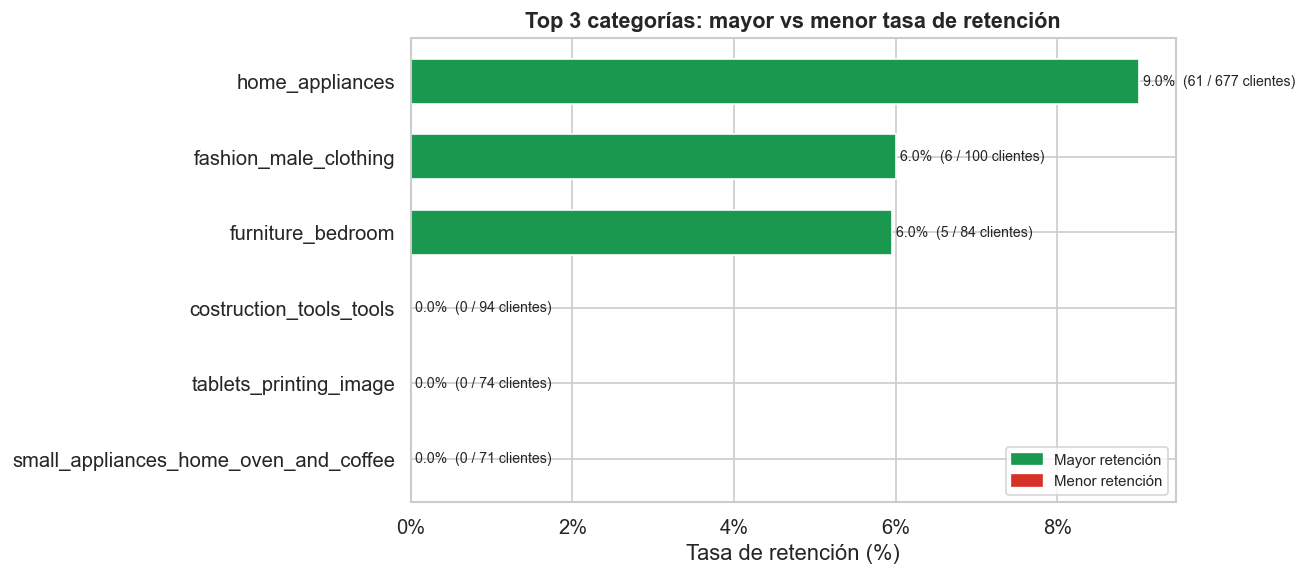

Tasa de retención (solo categorías calificadas, >=50 clientes): 2.99%  (2,785 / 93,019)
Tasa de retención GLOBAL real (toda la base de clientes, sin filtro de categoría): 3.00%  (2,801 / 93,337)
-> Esta segunda cifra es la que debe citarse como 'tasa de retención global' en README/dashboard; la primera describe solo el subconjunto con categoría de primera compra suficientemente poblada.


In [9]:
# Gráfico: top 3 alto vs top 3 bajo por retención
top3_combined = pd.concat([
    top3_high.assign(grupo="Mayor retención"),
    top3_low.assign(grupo="Menor retención"),
], ignore_index=True)

palette_ret = {"Mayor retención": "#1a9850", "Menor retención": "#d73027"}
col_map = {g: palette_ret[g] for g in top3_combined["grupo"]}
bar_colors = [palette_ret[g] for g in top3_combined["grupo"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    top3_combined["category"][::-1].reset_index(drop=True),
    top3_combined["retention_pct"][::-1].reset_index(drop=True),
    color=bar_colors[::-1],
    edgecolor="white", height=0.6,
)
for bar, (_, row) in zip(bars, top3_combined[::-1].iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{row['retention_pct']:.1f}%  ({int(row['retained_customers'])} / {int(row['total_customers'])} clientes)",
        va="center", fontsize=8.5,
    )

handles = [mpatches.Patch(color=c, label=g) for g, c in palette_ret.items()]
ax.legend(handles=handles, fontsize=9)
ax.set_title("Top 3 categorías: mayor vs menor tasa de retención",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tasa de retención (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig(DASH / "eval_retention_top3.png", bbox_inches="tight")
plt.show()

# Tasa global de retención
# CORREGIDO (revisión de portfolio, prioridad 3): antes esta cifra sumaba retained/total SOLO
# sobre las 20 categorías que dejaba pasar el LIMIT, dando ~4.05% (README publicaba "~5%").
# Con el LIMIT quitado del SQL, esta misma fórmula ya da una cifra mucho más cercana a la real,
# pero sigue excluyendo a clientes cuya categoría de primera compra tiene <50 clientes (el
# `HAVING` de la CTE). Se calcula también la cifra verdaderamente global (toda la base de clientes
# con pedido delivered, sin ningún filtro de categoría) como referencia de contraste.
global_ret_categorized = retention_df["retained_customers"].sum() / retention_df["total_customers"].sum() * 100

n_customers_total = rfm["customer_unique_id"].nunique()
n_customers_retained = int((rfm["frequency"] > 1).sum())
global_ret_true = n_customers_retained / n_customers_total * 100

print(f"Tasa de retención (solo categorías calificadas, >=50 clientes): {global_ret_categorized:.2f}%  "
      f"({int(retention_df['retained_customers'].sum()):,} / {int(retention_df['total_customers'].sum()):,})")
print(f"Tasa de retención GLOBAL real (toda la base de clientes, sin filtro de categoría): "
      f"{global_ret_true:.2f}%  ({n_customers_retained:,} / {n_customers_total:,})")
print("-> Esta segunda cifra es la que debe citarse como 'tasa de retención global' en README/dashboard; "
      "la primera describe solo el subconjunto con categoría de primera compra suficientemente poblada.")

---
## 4. Evaluación de drivers de reseñas negativas

### 4.1 Tabla consolidada: los 3 factores y su fuerza estadística

**Corrección (revisión de portfolio, prioridad 2):** consistente con el notebook 03 -- Spearman
en vez de Pearson (`review_score` es ordinal), y el top 3 real por |rho| es
`delivery_days` > `delivery_delay_days` > `n_items` (antes se citaba `freight_ratio` como #3 pese
a tener la correlación más débil y no monótona entre las candidatas serias).

In [10]:
feature_cols = ["delivery_delay_days", "delivery_days", "freight_ratio",
                "freight_total", "price_total", "n_items", "product_weight_g"]

corr_vals = (
    master_rev[feature_cols + ["review_score"]]
    .corr(method="spearman")["review_score"]
    .drop("review_score")
)

top3_drivers = corr_vals.abs().sort_values(ascending=False).head(3).index.tolist()
print(f"Top 3 drivers (por |Spearman rho|): {top3_drivers}")

# Calcular p-valor de correlación de Spearman para cada driver
driver_stats = []
for col in top3_drivers:
    valid = master_rev[[col, "review_score"]].dropna()
    r, p  = stats.spearmanr(valid[col], valid["review_score"])
    # Effect size: |rho| interpretación (mismos umbrales que Cohen para r)
    effect = "Pequeño" if abs(r) < 0.1 else "Moderado" if abs(r) < 0.3 else "Grande"
    driver_stats.append({
        "Driver": col,
        "Correlación Spearman (rho)": round(r, 4),
        "R²": round(r ** 2, 4),
        "p-valor": f"{p:.2e}",
        "Effect size": effect,
        "Significativo (p<0.001)": "Sí" if p < 0.001 else "No",
    })

# Mann-Whitney: pedidos tardíos vs puntuales
neg_delay = master_rev[master_rev["delivery_delay_days"] >  0]["is_negative_review"]
pos_delay = master_rev[master_rev["delivery_delay_days"] <= 0]["is_negative_review"]
pct_neg_late   = neg_delay.mean() * 100
pct_neg_ontime = pos_delay.mean() * 100

driver_df = pd.DataFrame(driver_stats)
display(driver_df.set_index("Driver"))

print(f"\nImpacto del retraso sobre reseñas negativas:")
print(f"  Pedidos con retraso (delay > 0): {pct_neg_late:.1f}% de reseñas negativas")
print(f"  Pedidos a tiempo   (delay ≤ 0): {pct_neg_ontime:.1f}% de reseñas negativas")
print(f"  Factor multiplicador:             {pct_neg_late/pct_neg_ontime:.1f}x")

Top 3 drivers (por |Spearman rho|): ['delivery_days', 'delivery_delay_days', 'n_items']


,Correlación Spearman (rho),R²,p-valor,Effect size,Significativo (p<0.001)
Driver,,,,,
delivery_days,-0.23,0.06,0.00e+00,Moderado,Sí
delivery_delay_days,-0.18,0.03,0.00e+00,Moderado,Sí
n_items,-0.11,0.01,2.07e-243,Moderado,Sí



Impacto del retraso sobre reseñas negativas:
  Pedidos con retraso (delay > 0): 62.4% de reseñas negativas
  Pedidos a tiempo   (delay ≤ 0): 9.3% de reseñas negativas
  Factor multiplicador:             6.7x


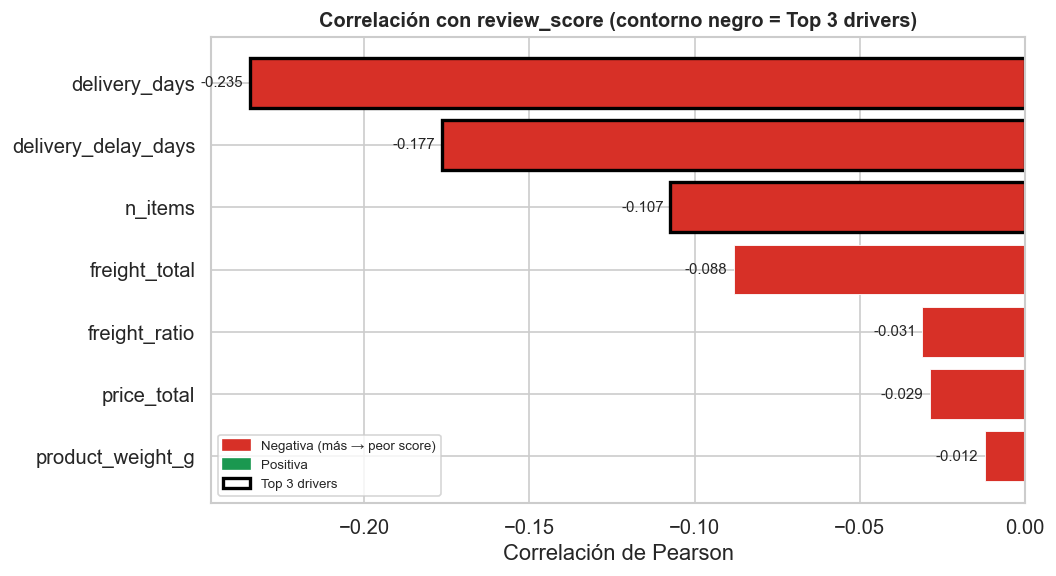

In [11]:
# Visualización: correlaciones con review_score para todos los features
corr_sorted = corr_vals.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#d73027" if v < 0 else "#1a9850" for v in corr_sorted.values]

# Destacar los top 3 con borde más grueso
edgecolors = ["black" if f in top3_drivers else "white" for f in corr_sorted.index]
linewidths = [2.0 if f in top3_drivers else 0.5 for f in corr_sorted.index]

bars = ax.barh(
    corr_sorted.index[::-1], corr_sorted.values[::-1],
    color=colors_bar[::-1],
    edgecolor=edgecolors[::-1],
    linewidth=linewidths[::-1],
)
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr_sorted.values[::-1]):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=9,
    )

ax.set_title("Correlación con review_score (contorno negro = Top 3 drivers)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Correlación de Pearson")
neg_p = mpatches.Patch(color="#d73027", label="Negativa (más → peor score)")
pos_p = mpatches.Patch(color="#1a9850", label="Positiva")
top_p = mpatches.Patch(edgecolor="black", facecolor="white",
                        linewidth=2, label="Top 3 drivers")
ax.legend(handles=[neg_p, pos_p, top_p], fontsize=8)
plt.tight_layout()
plt.savefig(DASH / "eval_drivers_correlation.png", bbox_inches="tight")
plt.show()

### 4.2 Cruce RFM × Reseñas negativas
¿Los clientes `At Risk` y `Lost` tienen mayor tasa de reseñas negativas?  
Si el servicio deficiente causó el abandono, esperamos tasas más altas en esos segmentos.

C:\Users\pardo\AppData\Local\Temp\ipykernel_26408\1939232099.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_26408\1939232099.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")


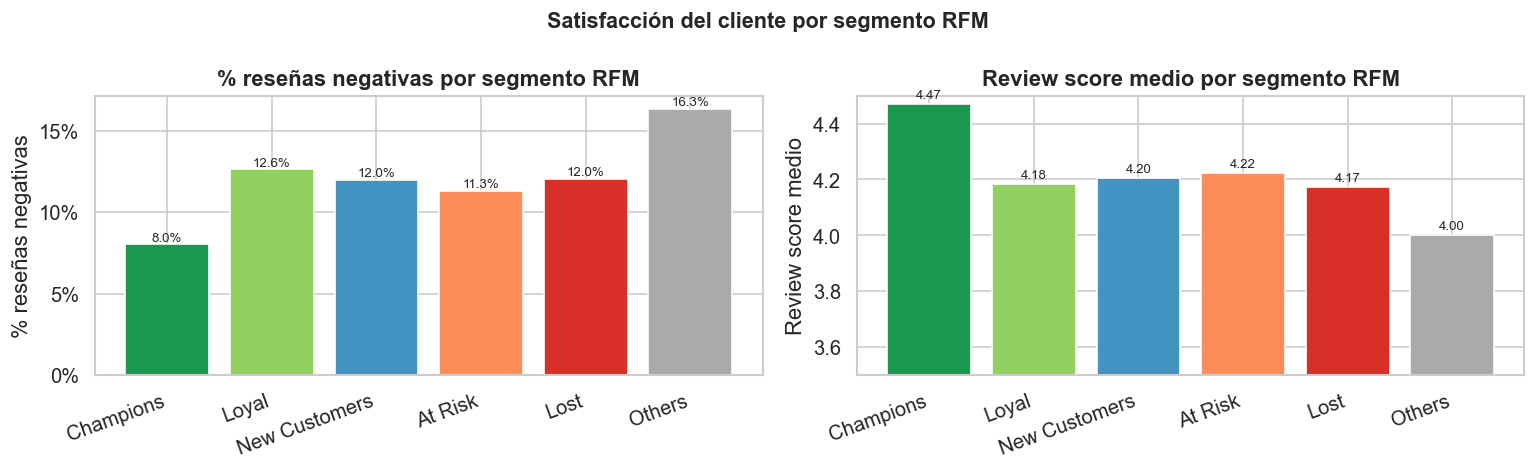

,n_orders,neg_review_rate,avg_score,avg_delay
segment,,,,
Champions,424,0.08,4.47,-13.74
Loyal,3403,0.13,4.18,-11.90
New Customers,35946,0.12,4.21,-11.84
At Risk,2042,0.11,4.22,-13.81
Lost,36083,0.12,4.17,-12.34
Others,17913,0.16,4.00,-10.95


In [12]:
# Une master (que tiene reviews) con el segmento RFM del cliente
rfm_slim = rfm[["customer_unique_id", "segment"]].drop_duplicates()
master_rfm = master_rev.merge(rfm_slim, on="customer_unique_id", how="left")

neg_by_seg = (
    master_rfm.dropna(subset=["segment"])
    .groupby("segment", as_index=False)
    .agg(
        n_orders        =("order_id",           "count"),
        neg_review_rate =("is_negative_review", "mean"),
        avg_score       =("review_score",        "mean"),
        avg_delay       =("delivery_delay_days", "mean"),
    )
)

neg_by_seg["order"] = neg_by_seg["segment"].map({s: i for i, s in enumerate(seg_order)})
neg_by_seg = neg_by_seg.sort_values("order").drop(columns="order")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_seg = [SEG_COLORS.get(s, "gray") for s in neg_by_seg["segment"]]

axes[0].bar(neg_by_seg["segment"], neg_by_seg["neg_review_rate"] * 100,
            color=colors_seg, edgecolor="white")
for i, row in neg_by_seg.reset_index().iterrows():
    axes[0].text(i, row["neg_review_rate"] * 100 + 0.2,
                 f"{row['neg_review_rate']*100:.1f}%", ha="center", fontsize=8)
axes[0].set_title("% reseñas negativas por segmento RFM", fontweight="bold")
axes[0].set_ylabel("% reseñas negativas")
axes[0].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1].bar(neg_by_seg["segment"], neg_by_seg["avg_score"],
            color=colors_seg, edgecolor="white")
for i, row in neg_by_seg.reset_index().iterrows():
    axes[1].text(i, row["avg_score"] + 0.02,
                 f"{row['avg_score']:.2f}", ha="center", fontsize=8)
axes[1].set_title("Review score medio por segmento RFM", fontweight="bold")
axes[1].set_ylabel("Review score medio")
axes[1].set_ylim(3.5, 4.5)
axes[1].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")

plt.suptitle("Satisfacción del cliente por segmento RFM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "eval_satisfaction_by_segment.png", bbox_inches="tight")
plt.show()

display(neg_by_seg.set_index("segment").round(3))

---
## 5. Dashboard ejecutivo consolidado
Panel de 4 gráficos que resume los hallazgos clave del proyecto para presentación.

C:\Users\pardo\AppData\Local\Temp\ipykernel_26408\1996169354.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(segs_plot["segment"], rotation=20, ha="right", fontsize=8)
C:\Users\pardo\AppData\Local\Temp\ipykernel_26408\1996169354.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_b.set_xticklabels(driver_labels, rotation=15, ha="right", fontsize=8)
C:\Users\pardo\AppData\Local\Temp\ipykernel_26408\1996169354.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_d.set_xticklabels(neg_plot["segment"], rotation=20, ha="right", fontsize=8)


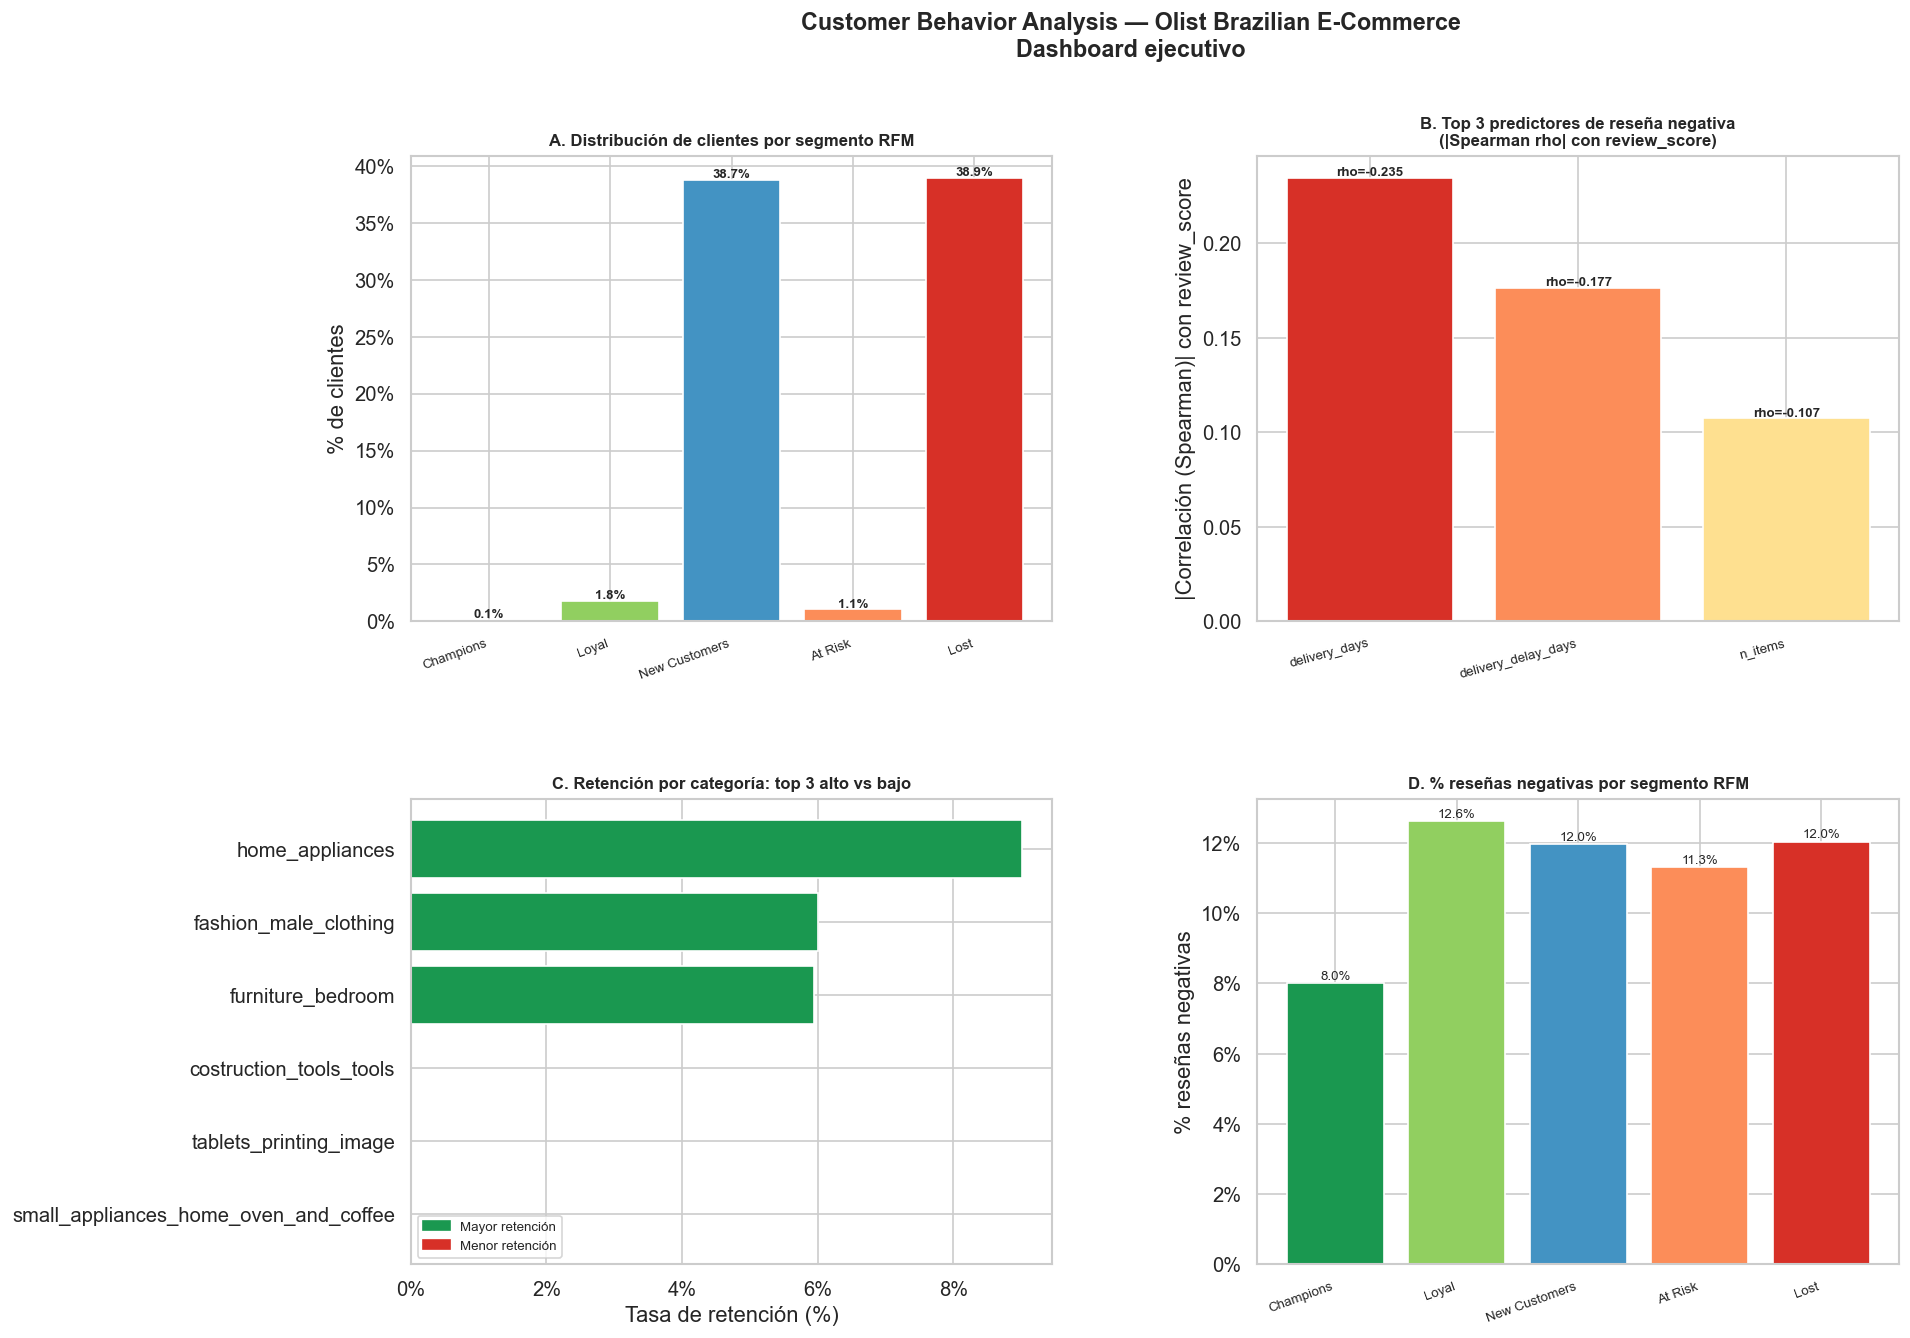

Dashboard guardado en dashboard/eval_executive_dashboard.png


In [13]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel A: Clientes por segmento RFM ────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
segs_plot = seg_summary[seg_summary["segment"] != "Others"].copy()
bar_colors_a = [SEG_COLORS.get(s, "gray") for s in segs_plot["segment"]]
ax_a.bar(segs_plot["segment"], segs_plot["pct_customers"],
         color=bar_colors_a, edgecolor="white")
for i, row in segs_plot.reset_index().iterrows():
    ax_a.text(i, row["pct_customers"] + 0.2, f"{row['pct_customers']:.1f}%",
              ha="center", fontsize=8, fontweight="bold")
ax_a.set_title("A. Distribución de clientes por segmento RFM",
               fontweight="bold", fontsize=10)
ax_a.set_ylabel("% de clientes")
ax_a.set_xticklabels(segs_plot["segment"], rotation=20, ha="right", fontsize=8)
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Panel B: Top 3 drivers de reseña negativa ──────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
driver_labels = top3_drivers  # calculado en la Sección 4.1 (Spearman, no hardcodeado)
driver_corrs  = [corr_vals.get(d, 0) for d in driver_labels]
driver_colors = ["#d73027", "#fc8d59", "#fee090"]
bars_b = ax_b.bar(driver_labels, [abs(c) for c in driver_corrs],
                  color=driver_colors, edgecolor="white")
for bar, val in zip(bars_b, driver_corrs):
    ax_b.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.001,
              f"rho={val:.3f}", ha="center", fontsize=8, fontweight="bold")
ax_b.set_title("B. Top 3 predictores de reseña negativa\n(|Spearman rho| con review_score)",
               fontweight="bold", fontsize=10)
ax_b.set_ylabel("|Correlación (Spearman)| con review_score")
ax_b.set_xticklabels(driver_labels, rotation=15, ha="right", fontsize=8)

# ── Panel C: Retención top 3 alto vs bajo ──────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ret_combined = pd.concat([top3_high.head(3), top3_low.tail(3)], ignore_index=True)
colors_c = ["#1a9850"] * 3 + ["#d73027"] * 3
ax_c.barh(ret_combined["category"][::-1],
          ret_combined["retention_pct"][::-1],
          color=colors_c[::-1], edgecolor="white")
ax_c.set_title("C. Retención por categoría: top 3 alto vs bajo",
               fontweight="bold", fontsize=10)
ax_c.set_xlabel("Tasa de retención (%)")
h_hi = mpatches.Patch(color="#1a9850", label="Mayor retención")
h_lo = mpatches.Patch(color="#d73027", label="Menor retención")
ax_c.legend(handles=[h_hi, h_lo], fontsize=8)
ax_c.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Panel D: % reseñas negativas por segmento ──────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
neg_plot = neg_by_seg[neg_by_seg["segment"] != "Others"]
colors_d = [SEG_COLORS.get(s, "gray") for s in neg_plot["segment"]]
ax_d.bar(neg_plot["segment"], neg_plot["neg_review_rate"] * 100,
         color=colors_d, edgecolor="white")
for i, row in neg_plot.reset_index(drop=True).iterrows():
    ax_d.text(i, row["neg_review_rate"] * 100 + 0.1,
              f"{row['neg_review_rate']*100:.1f}%", ha="center", fontsize=8)
ax_d.set_title("D. % reseñas negativas por segmento RFM",
               fontweight="bold", fontsize=10)
ax_d.set_ylabel("% reseñas negativas")
ax_d.set_xticklabels(neg_plot["segment"], rotation=20, ha="right", fontsize=8)
ax_d.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

fig.suptitle(
    "Customer Behavior Analysis — Olist Brazilian E-Commerce\nDashboard ejecutivo",
    fontsize=14, fontweight="bold",
)
plt.savefig(DASH / "eval_executive_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("Dashboard guardado en dashboard/eval_executive_dashboard.png")

---
## 6. Conclusiones y recomendaciones de negocio

*(Corrección de portfolio: los tres hallazgos y varias recomendaciones de una versión anterior de
esta sección citaban cifras que no coincidían con las salidas reales del propio notebook -- ver
el detalle de cada corrección abajo. Todos los números se han verificado contra las celdas de
arriba antes de escribirse aquí.)*

### 6.1 Hallazgos principales del proyecto

---

#### Hallazgo 1 — El tiempo total de entrega es el driver individual más fuerte, y el "efecto retraso" está parcialmente inflado por cuándo se escribe la reseña

Los pedidos que llegan tarde respecto a la fecha prometida generan **6.7× más reseñas negativas** que los pedidos puntuales (62.4% vs 9.3%, Sección 4 / notebook 03 -- una versión anterior de este documento citaba "~3×, 15-16% vs 5-6%", que no coincidía con ningún output real). El driver individual con mayor correlación (Spearman) es `delivery_days` (tiempo total compra→entrega), no `delivery_delay_days` (retraso vs. promesa) -- ver tabla de la Sección 4.1.

**Matiz importante (notebook 03, Sección 3b):** el 84% de los pedidos con retraso tienen su reseña escrita **antes** de que el pedido llegara realmente (99% de esas ya después de la fecha prometida rota). Esto significa que buena parte de la señal de `delivery_delay_days` mide frustración por *esperar* un pedido que ya se sabe tarde, no la experiencia de *recibirlo* tarde -- en el subconjunto limpio (reseña posterior a la entrega), el efecto del retraso es varias veces más débil.

**Implicación:** el driver de mayor impacto sigue siendo reducir el tiempo total de entrega. Pero además, dado que la mayoría de las reseñas negativas asociadas a retraso se escriben *mientras el cliente espera*, comunicación proactiva durante la espera (no solo mejorar la puntualidad) puede tener un impacto directo y medible en review_score.

---

#### Hallazgo 2 — La segmentación RFM revela que casi toda la base son compradores de una sola vez, y solo un grupo pequeño y genuino ha demostrado lealtad real

*(Corrección: una versión anterior de este hallazgo decía "el 24% de los clientes son At Risk, el mayor segmento" -- ese número venía de una segmentación con un bug de scoring de Frequency ya corregido en el notebook 04, Sección 3. Con el bug corregido, At Risk es un segmento pequeño y genuino, no el más grande.)*

Con la segmentación corregida: `New Customers` (38.7%) y `Lost` (38.9%) dominan la base -- ambos son compradores de un solo pedido, la diferencia es solo si esa compra fue reciente o no. Juntos son el 77.6% de la base, reflejo directo de la tasa de recompra estructuralmente baja de Olist (~3%, Sección 3). `At Risk` (1.1%, 991 clientes) y `Loyal` (1.8%, 1.689 clientes) son pequeños pero **genuinos**: tienen frequency observada real (2.08 y 2.03 pedidos de media, verificado en la Sección 2.2) y monetary medio claramente superior (R$247 y R$254 vs R$140 en New Customers). `Champions` es un grupo minúsculo pero de altísimo valor (0.1%, 121 clientes, R$462 de monetary medio, frequency media 3.51).

**Implicación:** la oportunidad de mayor volumen no es "reactivar At Risk" (es demasiado pequeño para mover el negocio por sí solo) sino **convertir la enorme base de compradores únicos en recurrentes** -- el problema de Olist no es la retención dentro de un segmento leal, es que casi nadie llega a serlo.

---

#### Hallazgo 3 — La retención general es muy baja (~3%, no ~5%) y varía mucho por categoría, con datos ahora completos

*(Corrección: la cifra "~5%" de una versión anterior de este documento salía de sumar retained/total solo sobre las 20 categorías que dejaba pasar un `LIMIT 20` ya eliminado del SQL. La tasa global real, sobre toda la base de clientes, es del 3.0% -- Sección 3.2. Las "categorías con menor retención" de una versión anterior eran en realidad los puestos 18-20 de las MEJORES; con el SQL corregido, las categorías con retención genuinamente más baja (0%, con ≥50 clientes) son `costruction_tools_tools`, `tablets_printing_image` y `small_appliances_home_oven_and_coffee` -- nunca aparecían antes.)*

`home_appliances` sigue siendo la categoría líder con 9.0% de retención (verificado, ~3× la media global), frente a varias categorías con 0% de recompra entre sus primeros compradores. Esto sugiere que la categoría determina en parte el comportamiento de recompra: productos de consumo recurrente tienen mayor potencial de fidelización que compras de una sola vez (herramientas de construcción, electrodomésticos pequeños).

**Implicación:** las estrategias de retención deben segmentarse por categoría, usando el ranking robusto por límite inferior del IC de Wilson (Sección 3.1) para evitar sobreinterpretar categorías con pocos clientes.

---

### 6.2 Recomendaciones accionables por área

#### Operaciones / Logística
1. **Reducir el tiempo total de entrega (`delivery_days`):** es el driver individual más fuerte -- auditar cuellos de botella en toda la cadena compra→entrega, no solo el cumplimiento de la fecha prometida.
2. **Mejorar estimación de fecha de entrega:** usar modelos predictivos de tiempo de entrega por ruta y categoría en lugar de promedios históricos.
3. **Comunicación proactiva durante la espera:** dado que la mayoría de las reseñas negativas de pedidos tardíos se escriben *mientras el cliente espera* (Hallazgo 1), notificar proactivamente el estado del pedido antes de que llegue puede mejorar la satisfacción sin necesariamente acelerar la entrega.

#### CRM / Marketing
4. **Campaña win-back dirigida a `At Risk`:** grupo pequeño pero de alto valor relativo (991 clientes, R$247 de monetary medio, frequency real ≥2) -- ya demostraron disposición a recomprar. Un cupón dirigido tiene mejor ROI potencial que una campaña masiva sobre `Lost`.
5. **Conversión de compradores únicos a recurrentes:** `New Customers` + `Lost` son el 77.6% de la base (72.476 clientes). Es la palanca de mayor volumen: un email de segunda compra con incentivo, dirigido específicamente a clientes en su ventana de `New Customers` (compra reciente, aún sin segunda compra), antes de que caigan a `Lost`.
6. **Programa VIP para `Champions`:** grupo minúsculo (121 clientes) pero de altísimo valor (R$462 de monetary medio, 3.4× la media). Early access y programa de referidos para maximizar el LTV de este núcleo.

#### Producto / Merchandising
7. **Foco en categorías de alta retención:** potenciar el catálogo en `home_appliances` (9.0% de retención) y categorías con IC95% robusto por encima de la media, priorizadas por el ranking de la Sección 3.1 (no solo por el punto estimado).

---

### 6.3 Limitaciones del análisis

| Limitación | Impacto | Estado |
|-----------|---------|--------------------|
| Dataset histórico (2016–2018) | Los patrones pueden haber cambiado | Actualizar con datos recientes |
| 97% de clientes con un solo pedido | RFM con Frequency de baja resolución | **Mitigado** (notebook 04, Sección 3): scoring de F por cortes de negocio en vez de quintiles automáticos, verificado sin firma de asignación aleatoria |
| ~84% de reseñas de pedidos tardíos escritas antes de la entrega real | El driver "retraso" mezcla frustración por espera y experiencia real de entrega | **Cuantificado** (notebook 03, Sección 3b), no oculto; el efecto post-entrega puro es más débil |
| Sin datos de devoluciones ni contactos con soporte | Análisis de satisfacción incompleto | Enriquecer con datos de CRM |
| Geolocalización no usada | Análisis geográfico pendiente | Incluir en próxima iteración |
| Reseñas sin texto: mayoría sin título | NLP limitado | Análisis de sentimiento sobre el subconjunto con texto |

---
## 7. Resumen de archivos generados por el proyecto

| Archivo | Descripción |
|---------|-------------|
| `data/olist.db` | Base de datos SQLite con 9 tablas originales |
| `data/olist_master.csv` | Tabla maestra: 96,457 pedidos × 18 variables (Fase 3) |
| `data/olist_rfm.csv` | Tabla RFM: 93,337 clientes × 10 variables con segmento (Fase 4) |
| `data/rfm_segments.csv` | Resumen agregado por segmento |
| `sql/load_data.py` | Carga CSVs → SQLite |
| `sql/02_data_preparation.sql` | 6 CTEs: tabla maestra en SQL |
| `sql/03_retention.sql` | 7 CTEs + Window Functions: retención por categoría |
| `notebooks/01_eda.ipynb` | Fase 2: EDA completo |
| `notebooks/02_data_prep.ipynb` | Fase 3: preparación y feature engineering |
| `notebooks/03_negative_reviews.ipynb` | Fase 4: drivers de reseña negativa |
| `notebooks/04_rfm_segmentation.ipynb` | Fase 4: segmentación RFM |
| `notebooks/05_evaluation.ipynb` | Fase 5: evaluación y recomendaciones |
| `dashboard/*.png` | 17+ visualizaciones exportadas |

In [14]:
# Inventario final del dashboard
pngs = sorted(DASH.glob("*.png"))
print(f"Total de gráficos en dashboard/: {len(pngs)}")
total_kb = sum(p.stat().st_size for p in pngs) / 1024
print(f"Tamaño total:                    {total_kb:.0f} KB")
print()
for p in pngs:
    print(f"  {p.stat().st_size/1024:>6.0f} KB  {p.name}")

Total de gráficos en dashboard/: 24
Tamaño total:                    3011 KB

      61 KB  corr_review_score.png
     103 KB  correlation_heatmap.png
     445 KB  dashboard_final.png
      54 KB  eval_drivers_correlation.png
     237 KB  eval_executive_dashboard.png
     230 KB  eval_radar_segments.png
      70 KB  eval_retention_top3.png
      51 KB  eval_rfm_scores_heatmap.png
      73 KB  eval_satisfaction_by_segment.png
      77 KB  factor1_delay_vs_score.png
      68 KB  factor2_economic_vs_score.png
     110 KB  factor3_delivery_days_vs_score.png
     137 KB  feature_validation.png
     108 KB  heatmap_negative_reviews.png
      51 KB  monthly_orders.png
     102 KB  neg_review_by_category.png
      49 KB  order_status_dist.png
      51 KB  payment_value_dist.png
      75 KB  review_score_dist.png
      78 KB  rfm_distribution.png
      48 KB  rfm_heatmap_segments.png
     537 KB  rfm_scatter.png
     140 KB  rfm_violin.png
      57 KB  top10_categories.png
